# Step 2 — Data Cleaning & Preparation

Before training, we need to:
1. **Filter bad samples** — remove zeros and physical outliers in the 4 target columns
2. **Understand the distributions** — decide whether to apply log-transform or standard normalisation
3. **Fit and save a normaliser** — so the same transform can be applied at inference time
4. **Subsample the training set** — 50,000 clean samples for CPU-friendly training
5. **Plot distributions** — verify the cleaned & normalised targets look sensible

## 2.1 Imports & Paths

In [1]:
import os, json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DATA_DIR = "/Users/wen/Desktop/project/archive"
OUT_DIR  = os.path.dirname(os.path.abspath("__file__"))

HDF5_FILES = {
    "train" : os.path.join(DATA_DIR, "5x64x64_training_with_morphology.hdf5"),
    "val"   : os.path.join(DATA_DIR, "5x64x64_validation_with_morphology.hdf5"),
    "test"  : os.path.join(DATA_DIR, "5x64x64_testing_with_morphology.hdf5"),
}

# Using g-band to match evaluate_wy.py which also uses image[0] = g-band
TARGET_COLS = ["g_ellipticity", "g_major_axis", "g_sersic_index", "g_isophotal_area"]
TRAIN_SUBSAMPLE = 50_000

## 2.2 Raw Distributions

Before filtering, plot the raw histograms of all 4 target columns on the full training set.  
This reveals the shape of each distribution and guides the choice of transform (log vs. standardise).

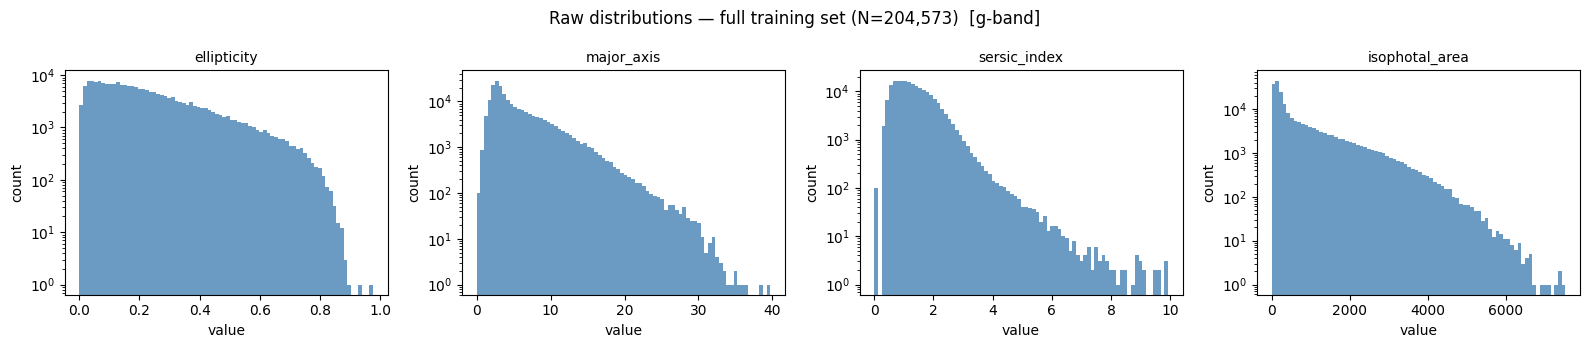

Saved dist_raw.png


In [2]:
with h5py.File(HDF5_FILES["train"], "r") as f:
    raw = {col: f[col][:] for col in TARGET_COLS}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle("Raw distributions — full training set (N=204,573)  [g-band]", fontsize=12)

for ax, col in zip(axes, TARGET_COLS):
    ax.hist(raw[col], bins=80, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(col.replace("g_", ""), fontsize=10)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
    ax.set_yscale("log")

plt.tight_layout()
plt.savefig("dist_raw.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved dist_raw.png")

## 2.3 Filtering Rules

We remove samples that are physically implausible or represent measurement failures.  
Using **g-band** columns to match `evaluate_wy.py` (which also uses `image[0]` = g-band).

| Column | Rule | Reason |
|--------|------|--------|
| `g_ellipticity` | `> 0` and `<= 1` | 0 = measurement failed; >1 is unphysical |
| `g_major_axis` | `> 0` | 0 = unresolved / failed fit |
| `g_sersic_index` | `> 0` and `< 10` | 0 = failed; =10 is the hard cap |
| `g_isophotal_area` | `> 0` | 0 = no detected isophote |

In [3]:
def build_clean_mask(f):
    """Return boolean array: True = keep this sample."""
    e   = f["g_ellipticity"][:]
    maj = f["g_major_axis"][:]
    n   = f["g_sersic_index"][:]
    iso = f["g_isophotal_area"][:]

    mask = (
        np.isfinite(e)   & (e   >  0) & (e   <= 1.0) &
        np.isfinite(maj) & (maj >  0) &
        np.isfinite(n)   & (n   >  0) & (n   <  10.0) &
        np.isfinite(iso) & (iso >  0)
    )
    return mask

print(f"{'Split':<8}  {'Total':>8}  {'Clean':>8}  {'Removed':>8}  {'% kept':>7}")
print("-" * 48)
masks = {}
for split, path in HDF5_FILES.items():
    with h5py.File(path, "r") as f:
        mask = build_clean_mask(f)
    masks[split] = mask
    total   = len(mask)
    clean   = mask.sum()
    removed = total - clean
    print(f"{split:<8}  {total:>8,}  {clean:>8,}  {removed:>8,}  {100*clean/total:>6.1f}%")

Split        Total     Clean   Removed   % kept
------------------------------------------------
train      204,573   204,469       104    99.9%
val         40,914    40,890        24    99.9%
test        40,914    40,891        23    99.9%


## 2.4 Choose Transform Strategy

Looking at the raw distributions:
- **`i_ellipticity`** — roughly uniform/bell between 0–1 → **standardise** (subtract mean, divide std)
- **`i_major_axis`** — right-skewed → **log1p then standardise**
- **`i_sersic_index`** — right-skewed → **log then standardise**
- **`i_isophotal_area`** — heavily right-skewed (range 0–7729) → **log then standardise**

We fit all statistics **only on the clean training indices** (no data leakage from val/test).  
The resulting parameters are saved to `normaliser.json` so they can be reloaded at inference time.

In [4]:
TRANSFORMS = {
    "g_ellipticity"  : "none",
    "g_major_axis"   : "log1p",
    "g_sersic_index" : "log",
    "g_isophotal_area": "log",
}

def apply_transform(arr, kind):
    if kind == "log1p": return np.log1p(arr)
    if kind == "log":   return np.log(arr)
    return arr.copy()

def invert_transform(arr, kind):
    if kind == "log1p": return np.expm1(arr)
    if kind == "log":   return np.exp(arr)
    return arr.copy()

with h5py.File(HDF5_FILES["train"], "r") as f:
    train_mask = masks["train"]
    clean_vals = {col: f[col][:][train_mask] for col in TARGET_COLS}

normaliser = {}
for col in TARGET_COLS:
    t_vals = apply_transform(clean_vals[col], TRANSFORMS[col])
    normaliser[col] = {
        "transform" : TRANSFORMS[col],
        "mean"      : float(t_vals.mean()),
        "std"       : float(t_vals.std()),
    }
    print(f"{col:<24}  transform={TRANSFORMS[col]:<6}  "
          f"mean={normaliser[col]['mean']:.4f}  std={normaliser[col]['std']:.4f}")

with open("normaliser.json", "w") as fp:
    json.dump(normaliser, fp, indent=2)
print("\nSaved normaliser.json")

g_ellipticity             transform=none    mean=0.2301  std=0.1718
g_major_axis              transform=log1p   mean=1.7203  std=0.5369
g_sersic_index            transform=log     mean=0.1788  std=0.5016
g_isophotal_area          transform=log     mean=5.7357  std=1.3523

Saved normaliser.json


## 2.5 Subsample Training Set & Save Index Arrays

We take the first 50,000 clean samples from the training split.  
For val and test we keep all clean samples.  
The selected integer indices are saved as `.npy` files — the DataLoader in Step 4 will use these to slice into the HDF5 without loading everything into memory.

In [5]:
rng = np.random.default_rng(42)

split_indices = {}
for split, path in HDF5_FILES.items():
    clean_idx = np.where(masks[split])[0]
    if split == "train":
        chosen = rng.choice(clean_idx, size=TRAIN_SUBSAMPLE, replace=False)
        chosen.sort()
    else:
        chosen = clean_idx
    split_indices[split] = chosen
    np.save(f"indices_{split}.npy", chosen)
    print(f"{split:<8}  clean={len(clean_idx):>7,}  used={len(chosen):>7,}  saved indices_{split}.npy")

train     clean=204,469  used= 50,000  saved indices_train.npy
val       clean= 40,890  used= 40,890  saved indices_val.npy
test      clean= 40,891  used= 40,891  saved indices_test.npy


## 2.6 Distribution Plots: Raw vs Cleaned vs Normalised

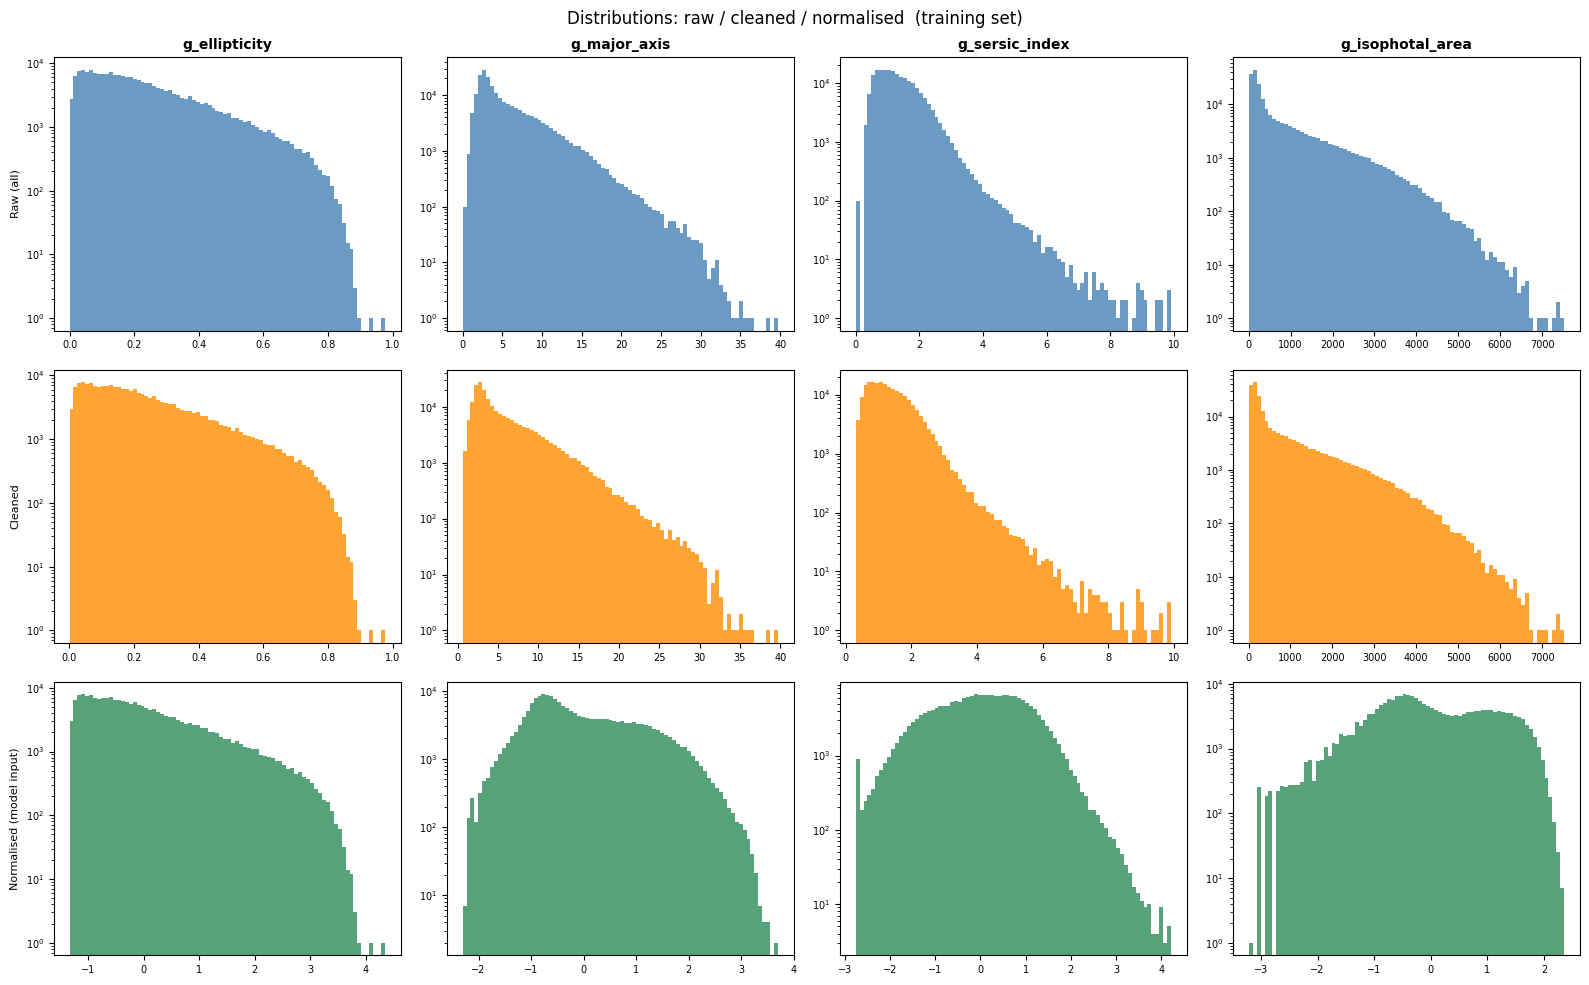

Saved dist_all_stages.png


In [6]:
with h5py.File(HDF5_FILES["train"], "r") as f:
    clean_vals = {col: f[col][:][masks["train"]] for col in TARGET_COLS}

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("Distributions: raw / cleaned / normalised  (training set)", fontsize=12)
row_labels = ["Raw (all)", "Cleaned", "Normalised (model input)"]

for col_i, col in enumerate(TARGET_COLS):
    raw_all = raw[col]
    cleaned = clean_vals[col]
    t_vals  = apply_transform(cleaned, normaliser[col]["transform"])
    normed  = (t_vals - normaliser[col]["mean"]) / normaliser[col]["std"]

    for row_i, (data, title) in enumerate(zip(
        [raw_all, cleaned, normed], row_labels
    )):
        ax = axes[row_i, col_i]
        ax.hist(data, bins=80, color=["steelblue","darkorange","seagreen"][row_i],
                edgecolor="none", alpha=0.8)
        if row_i == 0:
            ax.set_title(col.replace("i_", ""), fontsize=10, fontweight="bold")
        ax.set_ylabel(title if col_i == 0 else "", fontsize=8)
        ax.set_yscale("log")
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("dist_all_stages.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved dist_all_stages.png")

## 2.7 Summary

| Split | Total | Clean | Used |
|-------|-------|-------|------|
| train | 204,573 | see above | 50,000 (random subsample) |
| val   | 40,914  | see above | all clean |
| test  | 40,914  | see above | all clean |

**Outputs written:**
- `normaliser.json` — transform type + mean/std for each target column
- `indices_train.npy`, `indices_val.npy`, `indices_test.npy` — HDF5 row indices for each split

**Next:** Step 3 — CNN model definition